# Fase 2 — Análisis Exploratorio de Datos (EDA)

Notebook con el **código y las visualizaciones** del EDA del dataset `Fruits/`.

> Las **conclusiones e interpretación** de estos resultados están en `reports/02_comprension_datos.md` (insumo para el informe IEEE). Aquí solo van código y figuras.

## 0. Configuración e importaciones

In [1]:
import sys
from pathlib import Path

# Localizar la raíz del proyecto (carpeta que contiene 'src') y exponerla en sys.path
root = Path.cwd()
while not (root / 'src').exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.dataset import (
    build_index, load_rgb,
    QUALITY_ORDER, QUALITY_PALETTE, MIN_SIDE, DATASET_DIR,
)

sns.set_theme(style='whitegrid')
SEED = 42
print('Proyecto:', root)
print('Dataset :', DATASET_DIR)

Proyecto: /home/heiner/Documentos/apo_III/proyecto_final/ETLInfrati
Dataset : /home/heiner/Documentos/apo_III/proyecto_final/ETLInfrati/Fruits


## 1. Indexado del dataset

Construye un DataFrame con una fila por imagen y sus metadatos (usa `build_index` de `src/data/dataset.py`).

In [2]:
df = build_index()
print(f'Total de imágenes indexadas: {len(df)}')
print(f'Corruptas/no abribles    : {int(df.corrupt.sum())}')
df.head()

Total de imágenes indexadas: 9515
Corruptas/no abribles    : 0


,path,fruit,quality,width,height,area,mode,format,corrupt,tiny
0,Fruits/Bad Quality_Fruits/Apple_Bad/rotated_by...,Apple,Bad,290,342,99180,RGB,PNG,False,False
1,Fruits/Bad Quality_Fruits/Apple_Bad/rotated_by...,Apple,Bad,424,404,171296,RGB,PNG,False,False
2,Fruits/Bad Quality_Fruits/Apple_Bad/rotated_by...,Apple,Bad,262,228,59736,RGB,PNG,False,False
3,Fruits/Bad Quality_Fruits/Apple_Bad/IMG-202606...,Apple,Bad,3024,4032,12192768,RGB,JPEG,False,False
4,Fruits/Bad Quality_Fruits/Apple_Bad/rotated_by...,Apple,Bad,182,192,34944,RGB,PNG,False,False


## 2. Distribución por clase de calidad (objetivo del modelo)

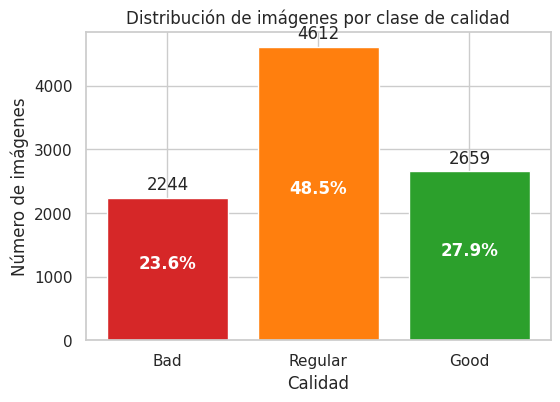

Ratio de desbalanceo (max/min): 2.06


In [3]:
counts = df['quality'].value_counts().reindex(QUALITY_ORDER)
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values,
              color=[QUALITY_PALETTE[q] for q in counts.index])
ax.bar_label(bars, padding=3)
total = counts.sum()
for i, v in enumerate(counts.values):
    ax.text(i, v/2, f'{100*v/total:.1f}%', ha='center', color='white', fontweight='bold')
ax.set_title('Distribución de imágenes por clase de calidad')
ax.set_xlabel('Calidad'); ax.set_ylabel('Número de imágenes')
plt.show()

ratio = counts.max() / counts.min()
print(f'Ratio de desbalanceo (max/min): {ratio:.2f}')

## 3. Distribución por tipo de fruta y calidad (18 clases finas)

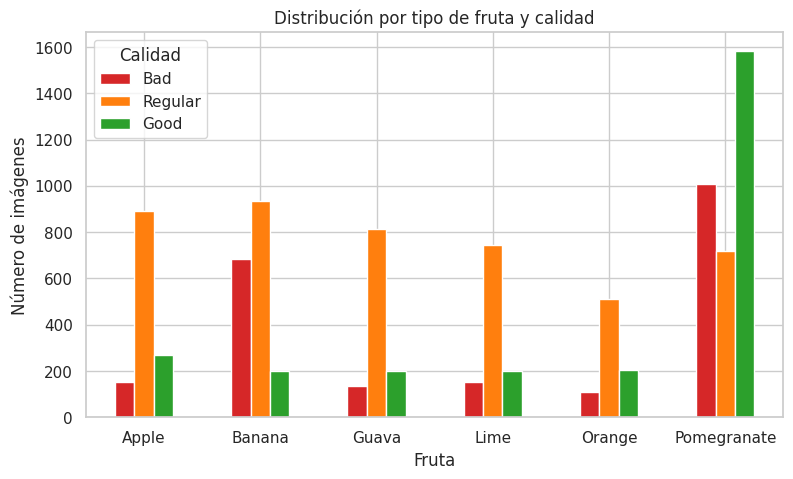

quality,Bad,Regular,Good
fruit,,,
Apple,153,890,267
Banana,684,936,201
Guava,135,813,200
Lime,152,743,200
Orange,111,510,206
Pomegranate,1009,720,1585


In [4]:
pivot = (df.pivot_table(index='fruit', columns='quality', values='path',
                        aggfunc='count', fill_value=0)
         .reindex(columns=QUALITY_ORDER))
fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(kind='bar', ax=ax, color=[QUALITY_PALETTE[q] for q in QUALITY_ORDER])
ax.set_title('Distribución por tipo de fruta y calidad')
ax.set_xlabel('Fruta'); ax.set_ylabel('Número de imágenes')
ax.legend(title='Calidad'); plt.xticks(rotation=0)
plt.show()
pivot

## 4. Resoluciones de las imágenes (escala log)

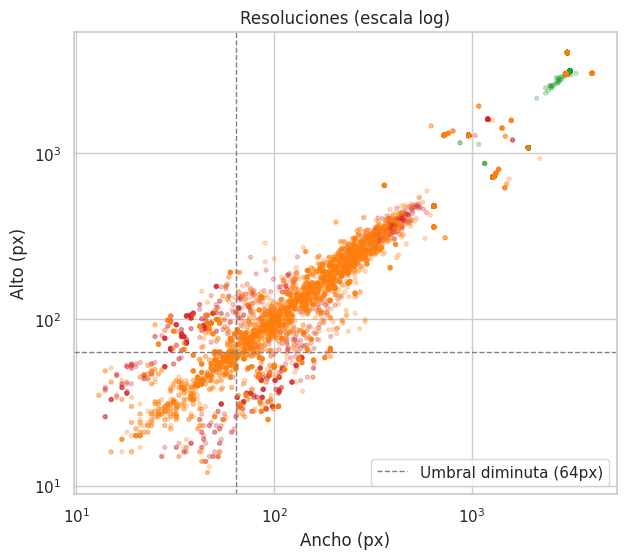

,width,height
min,13.0,12.0
25%,103.0,100.0
50%,495.0,434.0
75%,3120.0,3120.0
max,4032.0,4032.0


In [5]:
sub = df.dropna(subset=['width', 'height'])
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sub['width'], sub['height'], s=8, alpha=0.25,
           c=sub['quality'].map(QUALITY_PALETTE))
ax.set_xscale('log'); ax.set_yscale('log')
ax.axvline(MIN_SIDE, color='gray', ls='--', lw=1)
ax.axhline(MIN_SIDE, color='gray', ls='--', lw=1, label=f'Umbral diminuta ({MIN_SIDE}px)')
ax.set_title('Resoluciones (escala log)')
ax.set_xlabel('Ancho (px)'); ax.set_ylabel('Alto (px)'); ax.legend()
plt.show()

display(sub[['width', 'height']].describe().loc[['min','25%','50%','75%','max']])

## 5. Distribución del área de imagen (log10 de píxeles)

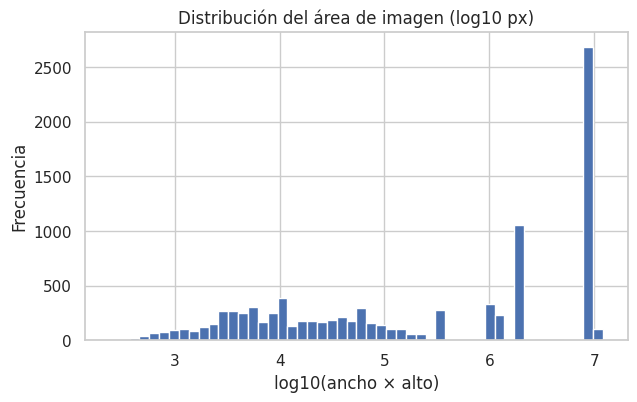

In [6]:
sub = df.dropna(subset=['area'])
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log10(sub['area']), bins=50, color='#4c72b0')
ax.set_title('Distribución del área de imagen (log10 px)')
ax.set_xlabel('log10(ancho × alto)'); ax.set_ylabel('Frecuencia')
plt.show()

## 6. Formatos de archivo y modos de color

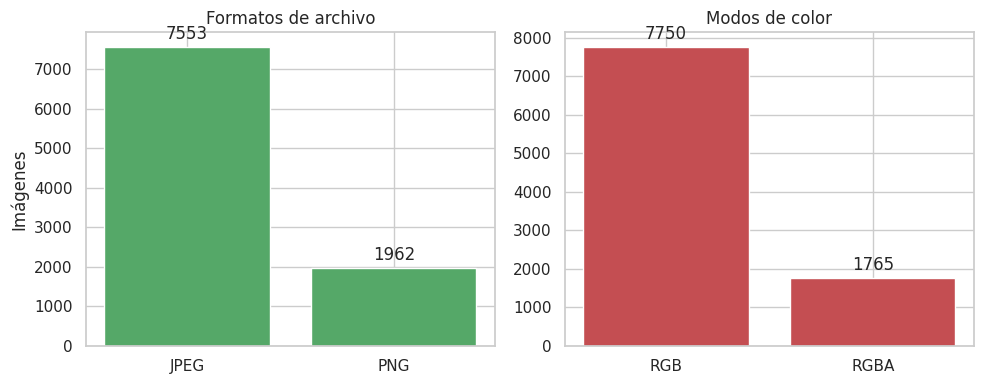

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fmt = df['format'].value_counts()
axes[0].bar(fmt.index.astype(str), fmt.values, color='#55a868')
axes[0].bar_label(axes[0].containers[0], padding=3)
axes[0].set_title('Formatos de archivo'); axes[0].set_ylabel('Imágenes')
mode = df['mode'].value_counts()
axes[1].bar(mode.index.astype(str), mode.values, color='#c44e52')
axes[1].bar_label(axes[1].containers[0], padding=3)
axes[1].set_title('Modos de color')
plt.tight_layout(); plt.show()

## 7. Procedencia: imágenes diminutas y canal alfa por clase

Tablas que evidencian la correlación entre características técnicas y la clase.

In [8]:
print('--- Diminutas (<%dpx) por calidad ---' % MIN_SIDE)
tiny_q = df.groupby('quality')['tiny'].agg(['sum','count'])
tiny_q['pct'] = (100*tiny_q['sum']/tiny_q['count']).round(1)
display(tiny_q.reindex(QUALITY_ORDER))

print('--- Diminutas por fruta ---')
tiny_f = df.groupby('fruit')['tiny'].agg(['sum','count'])
tiny_f['pct'] = (100*tiny_f['sum']/tiny_f['count']).round(1)
display(tiny_f)

print('--- Proporción de RGBA por calidad ---')
rgba = df.assign(rgba=df['mode'].eq('RGBA')).groupby('quality')['rgba'].mean().round(3)
display(rgba.reindex(QUALITY_ORDER))

--- Diminutas (<64px) por calidad ---


,sum,count,pct
quality,,,
Bad,470,2244,20.9
Regular,1242,4612,26.9
Good,0,2659,0.0


--- Diminutas por fruta ---


,sum,count,pct
fruit,,,
Apple,454,1310,34.7
Banana,870,1821,47.8
Guava,356,1148,31.0
Lime,32,1095,2.9
Orange,0,827,0.0
Pomegranate,0,3314,0.0


--- Proporción de RGBA por calidad ---


quality
Bad        0.000
Regular    0.383
Good       0.000
Name: rgba, dtype: float64

## 8. Muestras aleatorias por clase de calidad

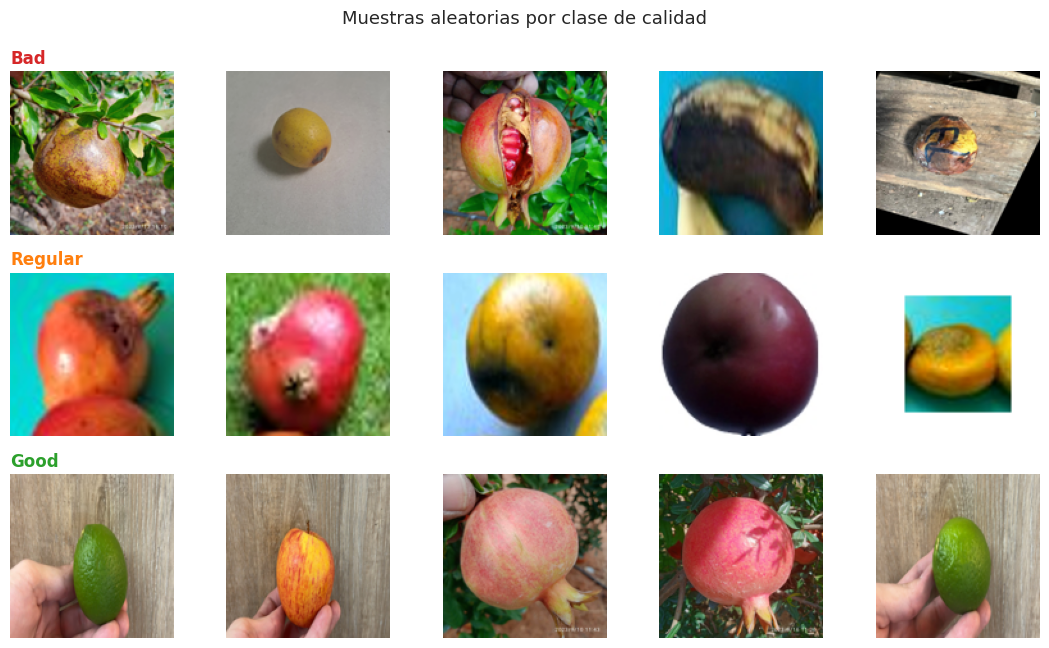

In [9]:
per_class = 5
fig, axes = plt.subplots(len(QUALITY_ORDER), per_class,
                         figsize=(2.2*per_class, 2.2*len(QUALITY_ORDER)))
for r, quality in enumerate(QUALITY_ORDER):
    pool = df[(df['quality']==quality) & (~df['corrupt']) & (~df['tiny'])]
    sample = pool.sample(min(per_class, len(pool)), random_state=SEED)
    for c in range(per_class):
        ax = axes[r, c]; ax.axis('off')
        if c < len(sample):
            row = sample.iloc[c]
            img = load_rgb(row['path'], size=(128, 128))
            ax.imshow(img)
            if c == 0:
                ax.set_title(quality, loc='left', fontsize=12,
                             color=QUALITY_PALETTE[quality], fontweight='bold')
fig.suptitle('Muestras aleatorias por clase de calidad', fontsize=13)
plt.tight_layout(); plt.show()

## 9. Resumen numérico

In [10]:
clean = df[(~df.corrupt) & (~df.tiny)]
print(f'Total imágenes            : {len(df)}')
print(f'Corruptas                 : {int(df.corrupt.sum())}')
print(f'Diminutas (<{MIN_SIDE}px)        : {int(df.tiny.sum())}')
print(f'Válidas (limpias)         : {len(clean)}')
print()
print('Distribución por calidad (todas):')
print(df['quality'].value_counts().reindex(QUALITY_ORDER).to_string())
print()
print('Distribución por calidad (sin diminutas):')
print(clean['quality'].value_counts().reindex(QUALITY_ORDER).to_string())
print()
print('Formatos:', df['format'].value_counts().to_dict())
print('Modos   :', df['mode'].value_counts().to_dict())

Total imágenes            : 9515
Corruptas                 : 0
Diminutas (<64px)        : 1712
Válidas (limpias)         : 7803

Distribución por calidad (todas):
quality
Bad        2244
Regular    4612
Good       2659

Distribución por calidad (sin diminutas):
quality
Bad        1774
Regular    3370
Good       2659

Formatos: {'JPEG': 7553, 'PNG': 1962}
Modos   : {'RGB': 7750, 'RGBA': 1765}
